<a href="https://colab.research.google.com/github/pavanviju/Bank-Credit-Scoring-Analysis/blob/main/Bank_Credit_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BANK CREDIT SCORING

This notebook demonstrates a complete end-to-end workflow for Bank Credit Scoring, including data ingestion, cleaning, exploratory analysis, visualization, and predictive modeling using Logistic Regression.



RA2311003010344 - Raj Bhalaji

RA2311003010348 - Adhithya Shivaa G T

RA2311003010354 - Pavan Viju


### Data Loading and Initial Setup

In this step, we create synthetic datasets representing customer demographics, transaction history, and loan default records to simulate a real banking environment.

In [ ]:
import pandas as pd

# Dataset 1: Customer Info
customers = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "income": [50000, 60000, 30000, 80000, 45000],
    "age": [25, 35, 29, 45, 33]
})

# Dataset 2: Transactions
transactions = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "spending": [20000, 25000, 15000, 30000, 22000]
})

# Dataset 3: Loan History
loans = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "defaulted": [0, 1, 0, 0, 1]  # 1 = risky
})

print(customers.head())
print(transactions.head())
print(loans.head())

   customer_id  income  age
0            1   50000   25
1            2   60000   35
2            3   30000   29
3            4   80000   45
4            5   45000   33
   customer_id  spending
0            1     20000
1            2     25000
2            3     15000
3            4     30000
4            5     22000
   customer_id  defaulted
0            1          0
1            2          1
2            3          0
3            4          0
4            5          1


Here we merge the disparate datasets into a single master dataframe, handle missing values, and engineer a 'savings' feature to better understand customer financial health.

In [ ]:
# Merge datasets
data = customers.merge(transactions, on="customer_id")
data = data.merge(loans, on="customer_id")

# Handle missing values
data.fillna(0, inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

# Convert data types
data["income"] = data["income"].astype(float)

# Create new feature
data["savings"] = data["income"] - data["spending"]

print(data)

   customer_id   income  age  spending  defaulted  savings
0            1  50000.0   25     20000          0  30000.0
1            2  60000.0   35     25000          1  35000.0
2            3  30000.0   29     15000          0  15000.0
3            4  80000.0   45     30000          0  50000.0
4            5  45000.0   33     22000          1  23000.0


We use statistical summaries to identify distributions and calculate the mean income of defaulters versus non-defaulters to find initial patterns.

In [ ]:
print(data.describe())

       customer_id        income        age      spending  defaulted  \
count     5.000000      5.000000   5.000000      5.000000   5.000000   
mean      3.000000  53000.000000  33.400000  22400.000000   0.400000   
std       1.581139  18574.175621   7.536577   5594.640292   0.547723   
min       1.000000  30000.000000  25.000000  15000.000000   0.000000   
25%       2.000000  45000.000000  29.000000  20000.000000   0.000000   
50%       3.000000  50000.000000  33.000000  22000.000000   0.000000   
75%       4.000000  60000.000000  35.000000  25000.000000   1.000000   
max       5.000000  80000.000000  45.000000  30000.000000   1.000000   

            savings  
count      5.000000  
mean   30600.000000  
std    13202.272532  
min    15000.000000  
25%    23000.000000  
50%    30000.000000  
75%    35000.000000  
max    50000.000000  


In [ ]:
print(data.groupby("defaulted")["income"].mean())

defaulted
0    53333.333333
1    52500.000000
Name: income, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['income', 'spending', 'savings']] = scaler.fit_transform(
    data[['income', 'spending', 'savings']]
)

### Feature Scaling
Standardizing features like income and spending ensures that the machine learning model isn't biased towards variables with higher absolute values.

In [ ]:
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1

data = data[(data['income'] >= Q1 - 1.5*IQR) & (data['income'] <= Q3 + 1.5*IQR)]

### Outlier Removal
Using the Interquartile Range (IQR) method, we filter out extreme data points in the income column to prevent model distortion.

### Data Visualization using Matplotlib

Visual representation of data through line plots, bar charts, and histograms to observe trends in income and spending behavior.

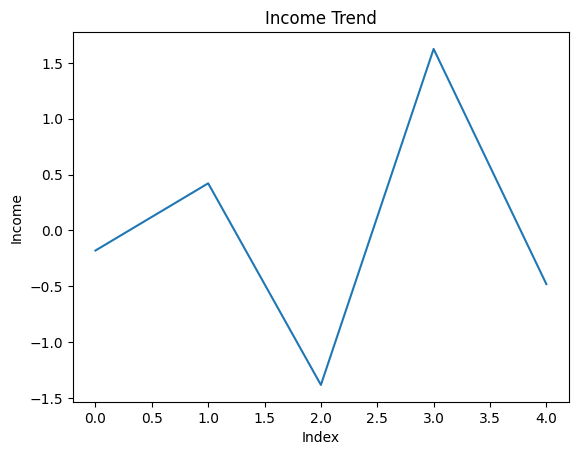

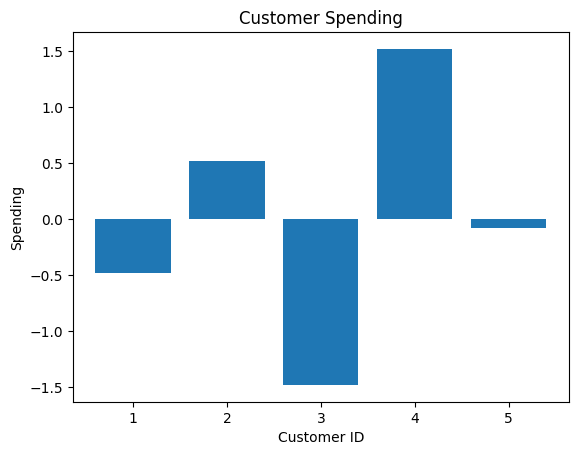

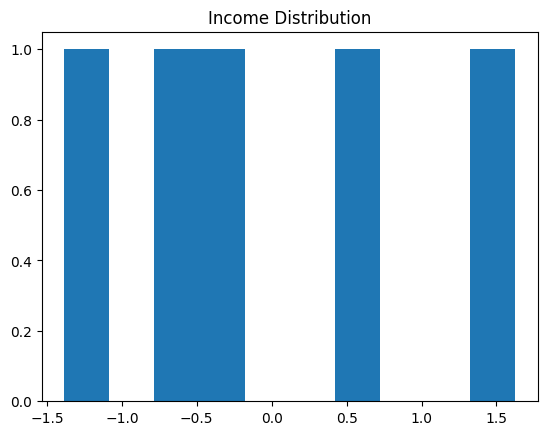

In [ ]:
import matplotlib.pyplot as plt

# Line Plot
plt.plot(data['income'])
plt.title("Income Trend")
plt.xlabel("Index")
plt.ylabel("Income")
plt.show()

# Bar Plot
plt.bar(data['customer_id'], data['spending'])
plt.title("Customer Spending")
plt.xlabel("Customer ID")
plt.ylabel("Spending")
plt.show()

# Histogram
plt.hist(data['income'])
plt.title("Income Distribution")
plt.show()

### Statistical Visualization using Seaborn

Using Seaborn for advanced analysis, including correlation heatmaps to see relationships between variables and boxplots to visualize income distribution by default status.

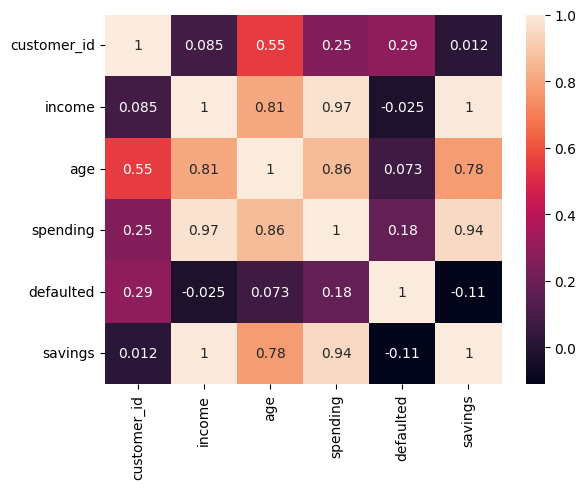

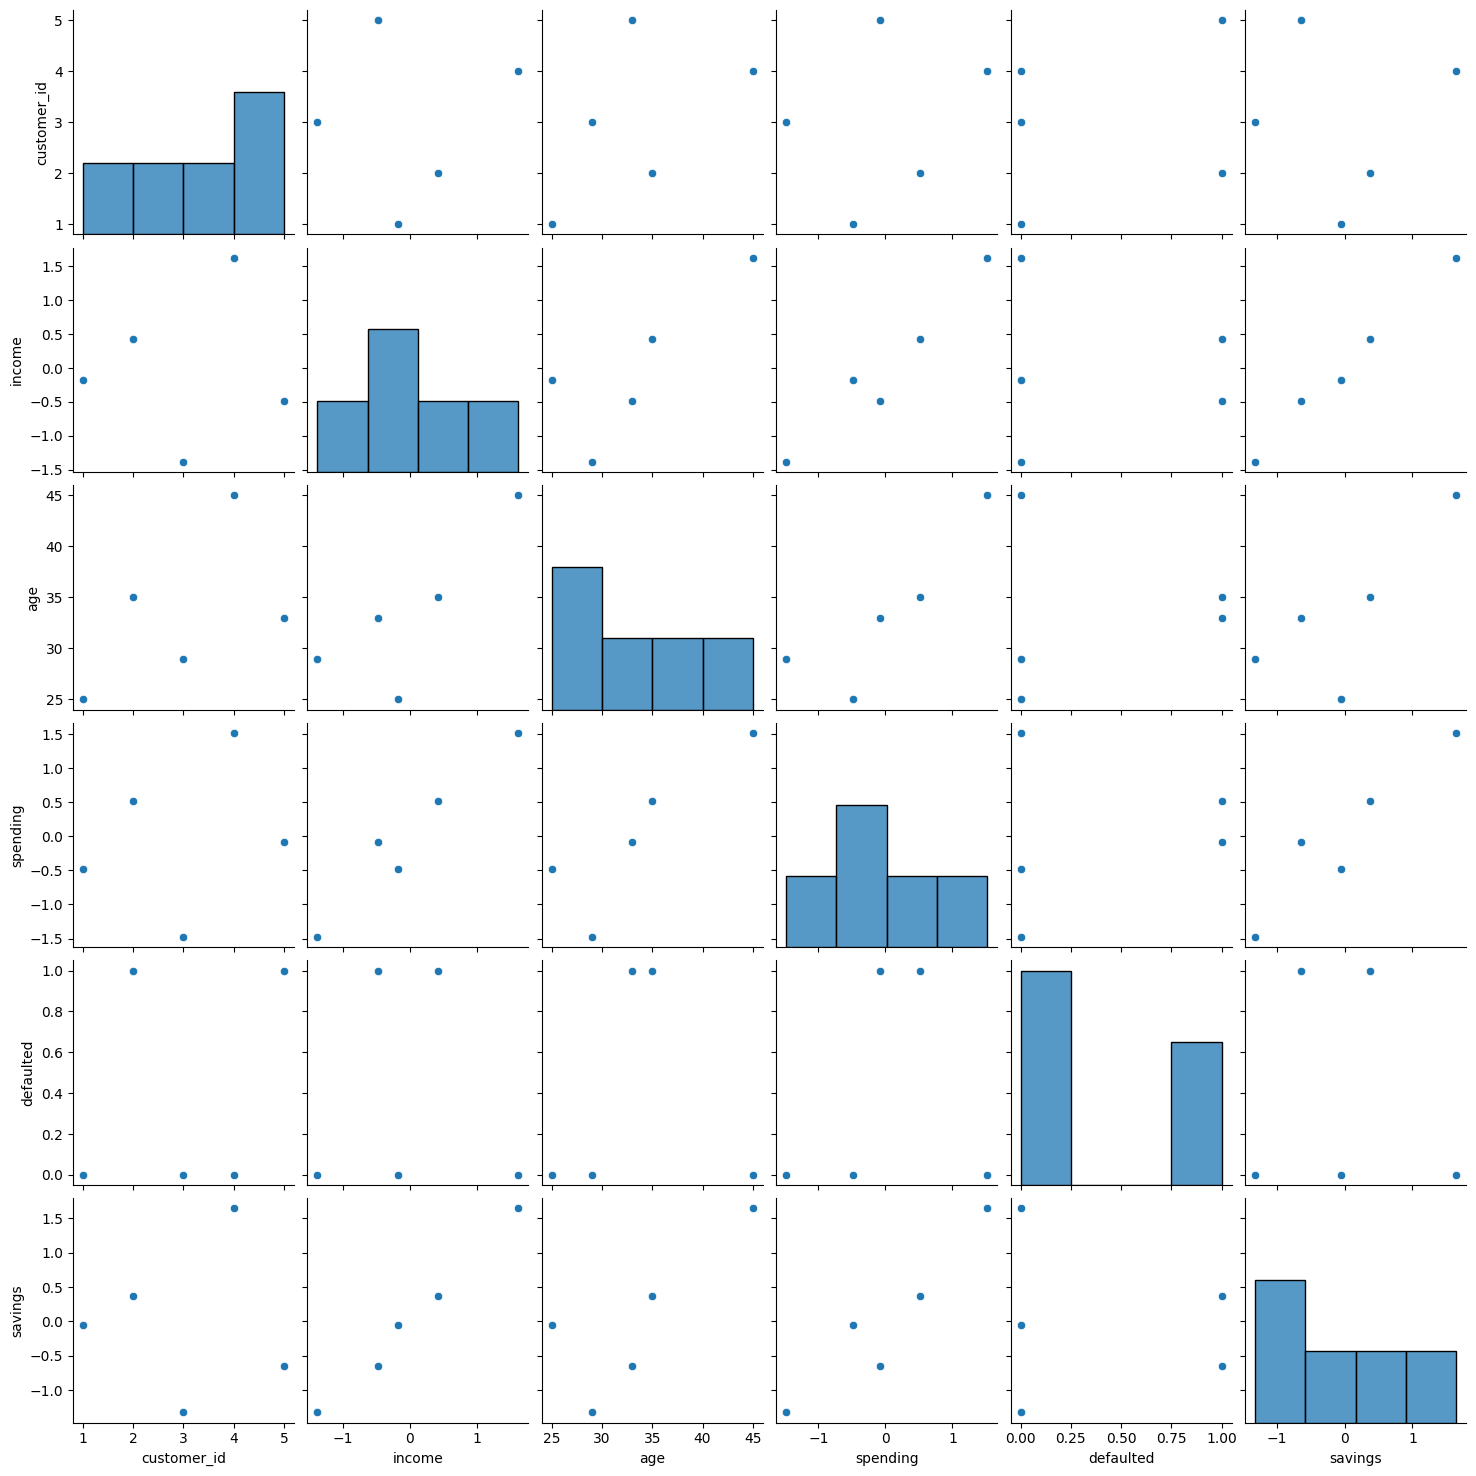

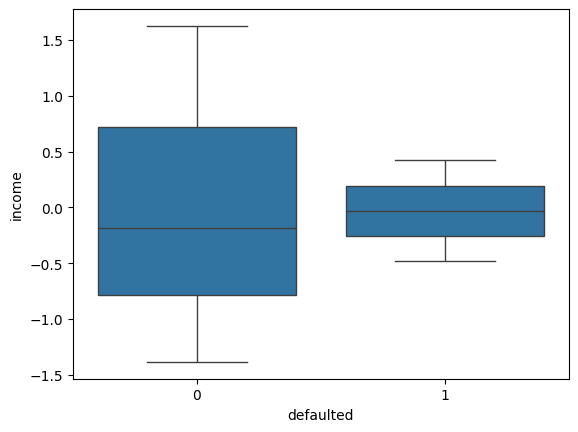

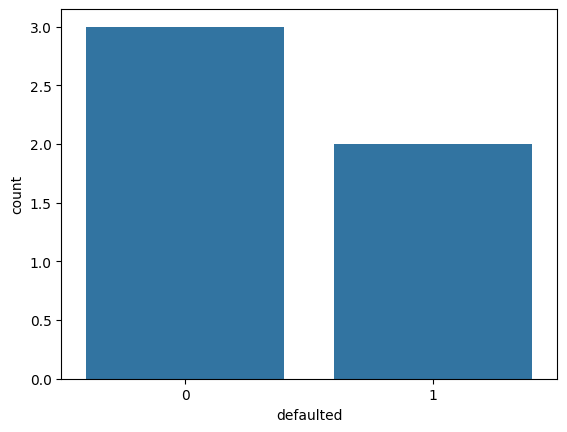

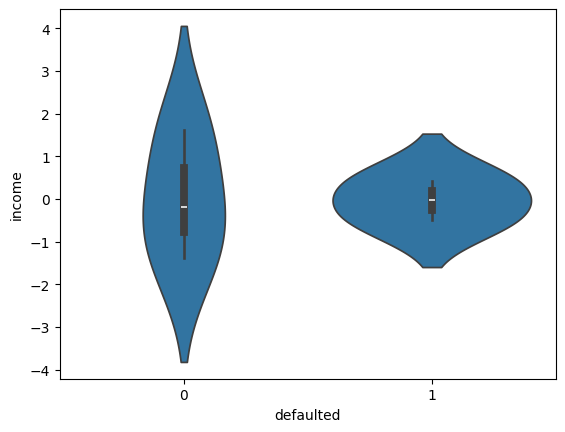

In [ ]:
import seaborn as sns

# Heatmap
sns.heatmap(data.corr(), annot=True)
plt.show()

# Pairplot
sns.pairplot(data)
plt.show()

# Boxplot
sns.boxplot(x='defaulted', y='income', data=data)
plt.show()

# Countplot
sns.countplot(x='defaulted', data=data)
plt.show()

# Violin plot
sns.violinplot(x='defaulted', y='income', data=data)
plt.show()

### Logistic Regression Model Training

We split the data into training and testing sets, then train a Logistic Regression model to predict the probability of a customer defaulting on a loan.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = data[['income', 'spending', 'savings']]
y = data['defaulted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)

print(predictions)

[1]


### Model Evaluation and Metrics

Comparing predicted outcomes against actual test data and calculating accuracy and confusion matrices to determine how well our scoring model performs.

In [ ]:
import pandas as pd

# Dataset 1: Customer Info
customers = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "income": [50000, 60000, 30000, 80000, 45000],
    "age": [25, 35, 29, 45, 33]
})

# Dataset 2: Transactions
transactions = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "spending": [20000, 25000, 15000, 30000, 22000]
})

# Dataset 3: Loan History
loans = pd.DataFrame({
    "customer_id": [1,2,3,4,5],
    "defaulted": [0, 1, 0, 0, 1]  # 1 = risky
})

print(customers.head())
print(transactions.head())
print(loans.head())

   customer_id  income  age
0            1   50000   25
1            2   60000   35
2            3   30000   29
3            4   80000   45
4            5   45000   33
   customer_id  spending
0            1     20000
1            2     25000
2            3     15000
3            4     30000
4            5     22000
   customer_id  defaulted
0            1          0
1            2          1
2            3          0
3            4          0
4            5          1


### Data Processing and Integration

In [ ]:
# Merge datasets
data = customers.merge(transactions, on="customer_id")
data = data.merge(loans, on="customer_id")

# Handle missing values
data.fillna(0, inplace=True)

# Remove duplicates
data.drop_duplicates(inplace=True)

# Convert data types
data["income"] = data["income"].astype(float)

# Create new feature
data["savings"] = data["income"] - data["spending"]

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  5 non-null      int64  
 1   income       5 non-null      float64
 2   age          5 non-null      int64  
 3   spending     5 non-null      int64  
 4   defaulted    5 non-null      int64  
 5   savings      5 non-null      float64
dtypes: float64(2), int64(4)
memory usage: 372.0 bytes
None


### Data Validation: Missing Value Check

In [ ]:
print(data.isnull().sum())

customer_id    0
income         0
age            0
spending       0
defaulted      0
savings        0
dtype: int64


In [ ]:
data.fillna(0, inplace=True)
print(data.isnull().sum())

customer_id    0
income         0
age            0
spending       0
defaulted      0
savings        0
dtype: int64


In [ ]:
data["savings"] = data["income"] - data["spending"]
print(data.head())

   customer_id   income  age  spending  defaulted  savings
0            1  50000.0   25     20000          0  30000.0
1            2  60000.0   35     25000          1  35000.0
2            3  30000.0   29     15000          0  15000.0
3            4  80000.0   45     30000          0  50000.0
4            5  45000.0   33     22000          1  23000.0


### Descriptive Statistics and Insights

In [ ]:
print(data.describe())

       customer_id        income        age      spending  defaulted  \
count     5.000000      5.000000   5.000000      5.000000   5.000000   
mean      3.000000  53000.000000  33.400000  22400.000000   0.400000   
std       1.581139  18574.175621   7.536577   5594.640292   0.547723   
min       1.000000  30000.000000  25.000000  15000.000000   0.000000   
25%       2.000000  45000.000000  29.000000  20000.000000   0.000000   
50%       3.000000  50000.000000  33.000000  22000.000000   0.000000   
75%       4.000000  60000.000000  35.000000  25000.000000   1.000000   
max       5.000000  80000.000000  45.000000  30000.000000   1.000000   

            savings  
count      5.000000  
mean   30600.000000  
std    13202.272532  
min    15000.000000  
25%    23000.000000  
50%    30000.000000  
75%    35000.000000  
max    50000.000000  


In [ ]:
print(data.groupby("defaulted")["income"].mean())

defaulted
0    53333.333333
1    52500.000000
Name: income, dtype: float64


### Data Scaling and Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[['income','spending','savings']] = scaler.fit_transform(
    data[['income','spending','savings']]
)

print(data.head())

   customer_id    income  age  spending  defaulted   savings
0            1 -0.180579   25 -0.479616          0 -0.050811
1            2  0.421350   35  0.519584          1  0.372614
2            3 -1.384437   29 -1.478817          0 -1.321085
3            4  1.625209   45  1.518785          0  1.642888
4            5 -0.481543   33 -0.079936          1 -0.643606


In [ ]:
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1, "Q3:", Q3)

Q1: -0.4815434123430768 Q3: 0.4213504858001922


### Outlier Filtering

In [ ]:
data = data[(data['income'] >= Q1 - 1.5*IQR) &
            (data['income'] <= Q3 + 1.5*IQR)]

print(data.shape)

(5, 6)


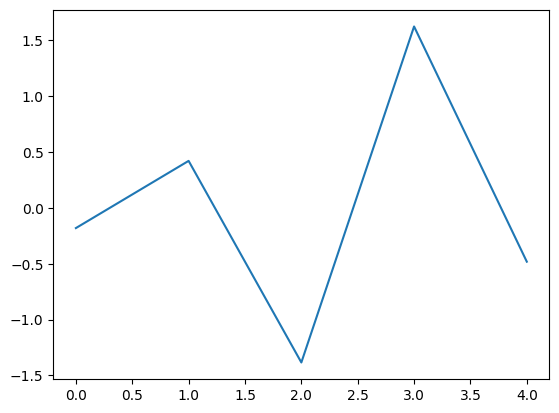

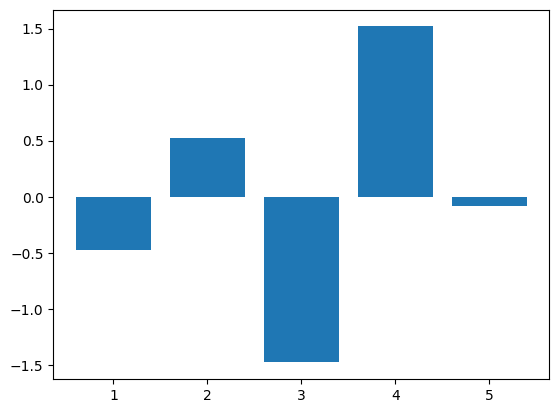

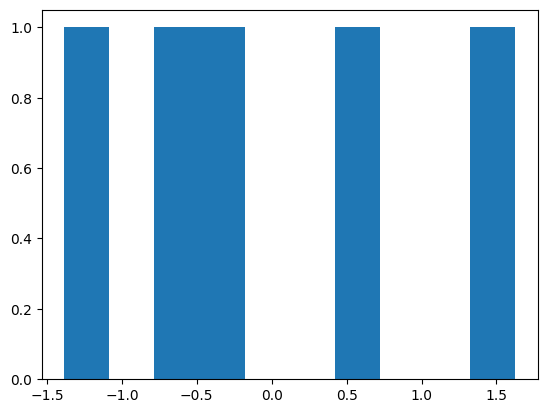

In [ ]:
import matplotlib.pyplot as plt

plt.plot(data['income'])
plt.show()

plt.bar(data['customer_id'], data['spending'])
plt.show()

plt.hist(data['income'])
plt.show()

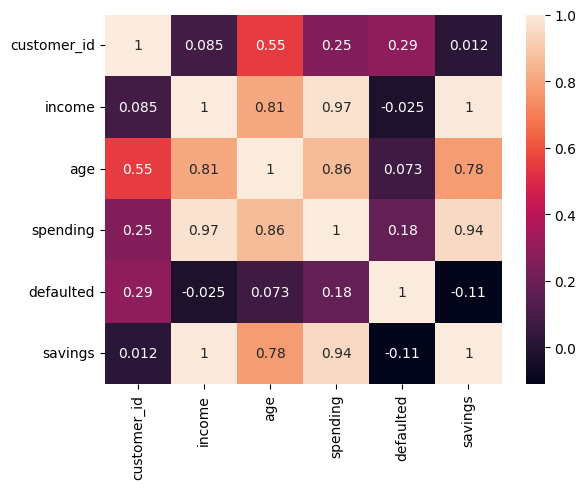

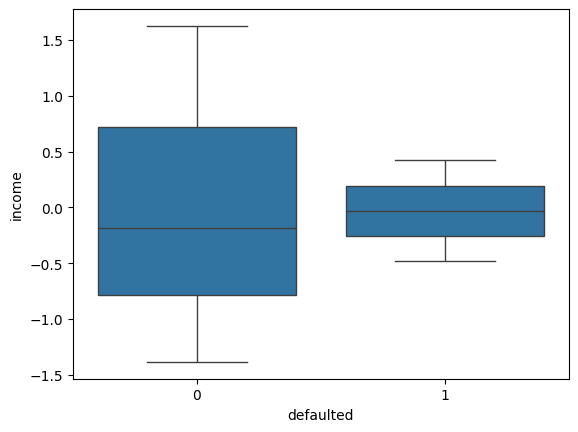

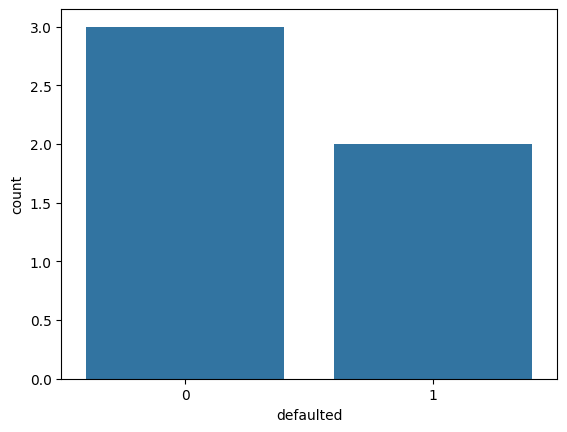

In [ ]:
import seaborn as sns

sns.heatmap(data.corr(), annot=True)
plt.show()

sns.boxplot(x='defaulted', y='income', data=data)
plt.show()

sns.countplot(x='defaulted', data=data)
plt.show()

In [ ]:
predictions = model.predict(X_test)

result = X_test.copy()
result["Actual"] = y_test
result["Predicted"] = predictions

print(result)

     income  spending   savings  Actual  Predicted
3  1.625209  1.518785  1.642888       0          1
1  0.421350  0.519584  0.372614       1          0


In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.0


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[0 1]
 [1 0]]


In [ ]:
data.loc[0, 'income'] = None   # Missing value
data.loc[1, 'spending'] = None

In [ ]:
print(data.isnull().sum())

customer_id    0
income         1
age            0
spending       1
defaulted      0
savings        0
dtype: int64


In [ ]:
data.fillna(0, inplace=True)
print(data.isnull().sum())

customer_id    0
income         0
age            0
spending       0
defaulted      0
savings        0
dtype: int64


In [ ]:
data = pd.concat([data, data.iloc[0:2]])

In [ ]:
print(data.duplicated().sum())   # BEFORE
data.drop_duplicates(inplace=True)
print(data.duplicated().sum())   # AFTER

2
0


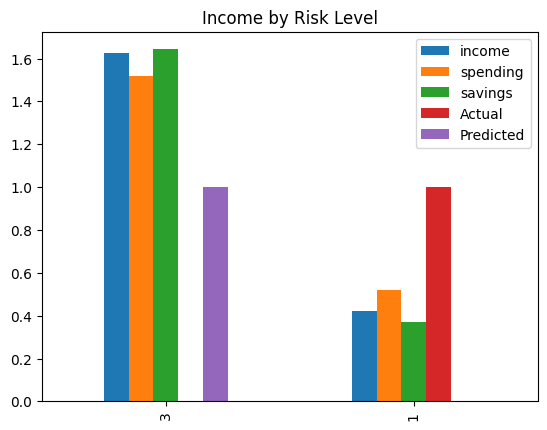

In [ ]:
result.plot(kind='bar')
plt.title("Income by Risk Level")
plt.show()

### Conclusion
This summary chart visualizes the final results, helping to distinguish how the model categorizes risk levels based on income and savings.